In [ ]:
import os

print(f"📂 Current Working Directory: {os.getcwd()}")
print("\n🗂️ DIRECTORY STRUCTURE (2 Levels Deep):")

start_path = '/content/drive/My Drive/MasterThesis_Archetypes' # Update if your base path is different

for root, dirs, files in os.walk(start_path):
    level = root.replace(start_path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f"{indent}📁 {os.path.basename(root)}/")
    subindent = ' ' * 4 * (level + 1)
    # limit to 5 files per folder to avoid spamming
    for f in files[:5]:
        print(f"{subindent}📄 {f}")
    if len(files) > 5:
        print(f"{subindent}... ({len(files)-5} more files)")

    # Stop recursion after 2 levels to keep output clean
    if level >= 2:
        del dirs[:]

📂 Current Working Directory: /content

🗂️ DIRECTORY STRUCTURE (2 Levels Deep):
📁 MasterThesis_Archetypes/
    📁 00_RawData/
        📁 Macro_PDFs/
            📄 1964__Mao-Tse-tung__QUOTEBOOK__Quotations-Chairman-Mao__EN.pdf.pdf
            📄 1938__Ernst-Hiemer__CHILD_PROP__Poisonous-Mushroom__EN.pdf
            📄 1921-1941__Adolf-Hitler__SPEECHES__Speeches-Collection__EN.pdf.pdf
            📄 2026__Gustavo-Petro__SPEECHES__Colombia-Potencia-de-la-Vida__ES.pdf
            📄 1900-1923__V-I-Lenin__COLLECTED__Collected-Works-Vol-3e__EN.pdf.pdf
            ... (33 more files)
        📁 Meso_RawData/
            📄 gdelt_test_sample.csv
            📄 gdelt_jan2017_test.csv
            📄 gdelt_meso_2017_raw.csv
            📄 gdelt_meso_2019_raw.csv
            📄 gdelt_meso_2020_raw.csv
            ... (1 more files)
        📁 Micro_RawData/
    📁 01_ProcessedCorpora/
        📄 macro_corpus_clean.csv
        📄 macro_corpus_CLEANED.csv
        📄 meso_corpus_clean.csv
        📄 meso_corpus_clean_2

In [ ]:
# ========================================
# NB2: MESO DATA - GDELT TEST (JAN 2017)
# ========================================

import os
import pandas as pd
from datetime import datetime, timedelta

# 1. INSTALL GDELT LIBRARY
try:
    from gdeltdoc import GdeltDoc, Filters
    print("✅ gdeltdoc library loaded.")
except ImportError:
    print("⬇️ Installing gdeltdoc...")
    !pip install -q gdeltdoc
    from gdeltdoc import GdeltDoc, Filters

# 2. SETUP PATHS
BASE_PATH = '/content/drive/My Drive/MasterThesis_Archetypes'
RAW_MESO_PATH = os.path.join(BASE_PATH, '00_RawData/Meso_RawData')
os.makedirs(RAW_MESO_PATH, exist_ok=True)

print(f"\n📂 Saving data to: {RAW_MESO_PATH}")

# 3. DEFINE "WEIMAR" THEMES
# These map to the GDELT "GKG" (Global Knowledge Graph) Themes
weimar_themes = [
    "ECON_UNEMPLOYMENT",      # Job precariousness
    "ECON_INFLATION",         # (Cost of living proxy)
    "GOV_CORRUPTION",         # Loss of legitimacy
    "SOC_POINTSOFINTEREST_OH_GOVERNMENT_BUILDINGS", # Often proxies for protests at capitals
    "DEMOCRACY",              # Crisis of democracy articles
    "MEDIA_CENSORSHIP",       # Distrust in truth
    "SCANDAL",                # Elite failure
    "EXTREMISM",              # Radicalization
    "POVERTY",                # Destitution
    "CRISISLEX_CRIME"         # Fear/Safety
]

# The previous method of creating a single long boolean query for 'keyword'
# resulted in a 'too long' error. Instead, we will query each theme individually.
# theme_query = f"({' OR '.join(weimar_themes)})"

print(f"\n🔍 Querying Themes individually: {weimar_themes[:3]}... (+{len(weimar_themes)-3} more)")

# 4. INITIALIZE API
gd = GdeltDoc()

# 5. RUN QUERY FOR JAN 2017 (US & GERMANY)
# We test just one month to check quality.

countries = [
    {"code": "US", "name": "United States"},
    {"code": "GM", "name": "Germany"}
]

all_articles = []

print("\n⏳ Fetching articles for January 2017...")

for country in countries:
    print(f"   > Querying {country['name']}...")

    country_articles_list = []
    # Distribute the num_records cap across themes to avoid hitting limits too quickly for single themes
    num_records_per_theme = max(1, 250 // len(weimar_themes))

    for theme in weimar_themes:
        print(f"     > Querying theme: {theme} for {country['name']}...")
        # Define Filter for each theme
        # start_date and end_date format: YYYY-MM-DD
        # We use 'country' to ensure the outlet is actually IN that country
        f = Filters(
            start_date="2017-01-01",
            end_date="2017-01-31",
            keyword=theme, # Query one theme at a time to avoid 'too long' error
            country=country['code'],
            num_records=num_records_per_theme # Cap per theme
        )

        try:
            articles = gd.article_search(f)
            if not articles.empty:
                articles['country_search'] = country['code']
                articles['gdelt_theme'] = theme # Add theme for identification
                country_articles_list.append(articles)
                print(f"       ✅ Found {len(articles)} articles for theme '{theme}'.")
            # else:
            #     print(f"       ⚠️ No articles found for theme '{theme}'.")
        except Exception as e:
            print(f"       ❌ Error for theme '{theme}': {e}")

    if country_articles_list:
        # Combine articles for the current country and drop duplicates based on url (formerly sourceurl)
        combined_country_df = pd.concat(country_articles_list, ignore_index=True).drop_duplicates(subset=['url'])
        all_articles.append(combined_country_df)
        print(f"     ✅ Successfully collected {len(combined_country_df)} unique articles for {country['name']}.")
    else:
        print(f"     ⚠️ No articles found for {country['name']} (check query/limits or themes).")

# 6. COMBINE & SAVE
if all_articles:
    df_gdelt = pd.concat(all_articles, ignore_index=True)

    # Preview
    print("\n" + "="*50)
    print("📰 HEADLINE PREVIEW (Does this look like Zeitgeist?)")
    print("="*50)
    print(df_gdelt[['title', 'url', 'gdelt_theme']].head(5).to_string(index=False)) # Changed sourceurl to url

    # Save
    filename = os.path.join(RAW_MESO_PATH, 'gdelt_jan2017_test.csv')
    df_gdelt.to_csv(filename, index=False)
    print(f"\n💾 Saved test file to: {filename}")
else:
    print("\n❌ No data collected. Check internet connection or GDELT status.")

✅ gdeltdoc library loaded.

📂 Saving data to: /content/drive/My Drive/MasterThesis_Archetypes/00_RawData/Meso_RawData

🔍 Querying Themes individually: ['ECON_UNEMPLOYMENT', 'ECON_INFLATION', 'GOV_CORRUPTION']... (+7 more)

⏳ Fetching articles for January 2017...
   > Querying United States...
     > Querying theme: ECON_UNEMPLOYMENT for United States...
     > Querying theme: ECON_INFLATION for United States...
     > Querying theme: GOV_CORRUPTION for United States...
     > Querying theme: SOC_POINTSOFINTEREST_OH_GOVERNMENT_BUILDINGS for United States...
       ❌ Error for theme 'SOC_POINTSOFINTEREST_OH_GOVERNMENT_BUILDINGS': 
     > Querying theme: DEMOCRACY for United States...
       ✅ Found 25 articles for theme 'DEMOCRACY'.
     > Querying theme: MEDIA_CENSORSHIP for United States...
       ❌ Error for theme 'MEDIA_CENSORSHIP': 
     > Querying theme: SCANDAL for United States...
       ✅ Found 25 articles for theme 'SCANDAL'.
     > Querying theme: EXTREMISM for United States..

In [ ]:
from gdeltdoc import GdeltDoc, Filters

gd = GdeltDoc()

print("🔎 Testing known-working combo: DEMOCRACY + US + Jan 2020")

f = Filters(
    start_date="2020-01-01",
    end_date="2020-01-31",
    keyword="DEMOCRACY",   # theme-style string, same as before
    country="US",
    num_records=25
)

try:
    articles = gd.article_search(f)
    if not articles.empty:
        print(f"✅ Found {len(articles)} articles")
        print("\n📰 Sample headlines:")
        print(articles[['title', 'seendate', 'url']].head(5).to_string(index=False))
    else:
        print("⚠️ No articles found for DEMOCRACY in Jan 2020 (US)")
except Exception as e:
    print(f"❌ Error: {e}")


🔎 Testing known-working combo: DEMOCRACY + US + Jan 2020
✅ Found 25 articles

📰 Sample headlines:
                                                                                               title         seendate                                                                                                    url
                                                    Dissatisfaction with democracy  at record high   20200129T024500Z          https://www.msn.com/en-xl/news/other/dissatisfaction-with-democracy-at-record-high/ar-BBZqfIB
Dissatisfaction with democracy  at record high  - world largest study -- Society Child -- Sott . net 20200131T141500Z https://www.sott.net/article/428327-Dissatisfaction-with-democracy-at-record-high-worlds-largest-study
                                      Україна піднялась у рейтингу  Індекс демократії  The Economist 20200127T173000Z                                          https://ukrainian.voanews.com/a/index-democratij/5261953.html
                  

In [ ]:
# ========================================
# PHASE 3: FULL DATA COLLECTION ENVIRONMENT
# ========================================

# Install missing libs
!pip install -q gdeltdoc langdetect pandas sentence-transformers torch tqdm

# Import & verify
import pandas as pd
import numpy as np
from gdeltdoc import GdeltDoc, Filters
from langdetect import detect
import os
from tqdm import tqdm
from sentence_transformers import SentenceTransformer

print("✅ All libraries ready!")
print(f"📂 Target folder: {RAW_MESO_PATH}")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 17.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
✅ All libraries ready!
📂 Target folder: /content/drive/My Drive/MasterThesis_Archetypes/00_RawData/Meso_RawData


In [ ]:
# ========================================
# BLOCK 5: DEFINE COLLECTION PARAMETERS
# ========================================

# Western Countries (ISO-2 codes)
WESTERN_COUNTRIES = ['US', 'CA', 'GB', 'DE', 'FR', 'NL', 'SE', 'NO', 'AU', 'NZ']

# 8 Keyword Queries (Your Radicalization Themes)
MESO_KEYWORDS = [
    "unemployment OR job loss OR economic crisis",                    # ECON
    "inflation OR cost of living OR housing crisis",                  # COST_OF_LIVING
    "COVID OR pandemic OR lockdown OR vaccine",                       # HEALTH_PANDEMIC
    "depression OR anxiety OR suicide OR mental health",              # HEALTH_MENTAL
    "protest OR riot OR social unrest OR demonstration",              # SOC_PROTEST
    "crime OR violence OR safety OR urban crime",                     # CRIME
    "migration OR refugee OR immigration OR border",                  # MIGRATION
    "extremism OR radicalization OR terrorism OR far-right OR far-left" # EXTREMISM
]

# Date range
START_YEAR = 2017
END_YEAR = 2026
YEARS_TO_COLLECT = list(range(START_YEAR, END_YEAR))

# Paths
BASE_PATH = '/content/drive/My Drive/MasterThesis_Archetypes'
RAW_MESO_PATH = os.path.join(BASE_PATH, '00_RawData/Meso_RawData')

# Batch settings (memory safe)
ARTICLES_PER_QUERY = 30  # Conservative
MAX_ARTICLES_PER_YEAR = 5000  # RAM safety cap

print(f"🎯 Target Scope:")
print(f"   Countries: {len(WESTERN_COUNTRIES)} ({', '.join(WESTERN_COUNTRIES)})")
print(f"   Keywords: {len(MESO_KEYWORDS)}")
print(f"   Years: {len(YEARS_TO_COLLECT)} ({START_YEAR}-{END_YEAR})")
print(f"   Projected: ~{len(WESTERN_COUNTRIES)*len(MESO_KEYWORDS)*ARTICLES_PER_QUERY*len(YEARS_TO_COLLECT)//1000}k articles")
print(f"\n📁 Raw folder: {RAW_MESO_PATH}")


🎯 Target Scope:
   Countries: 10 (US, CA, GB, DE, FR, NL, SE, NO, AU, NZ)
   Keywords: 8
   Years: 9 (2017-2026)
   Projected: ~21k articles

📁 Raw folder: /content/drive/My Drive/MasterThesis_Archetypes/00_RawData/Meso_RawData


In [ ]:
# ========================================
# BLOCK 3: FULL MESO DATA COLLECTION (Working Version)
# ========================================

gd = GdeltDoc()
all_data = []

# PROVEN KEYWORDS ONLY (shorter, single-concept)
PROVEN_KEYWORDS = [
    "unemployment",      # ECON (single word)
    "inflation",         # COST_OF_LIVING
    "covid",             # HEALTH_PANDEMIC
    "depression",        # HEALTH_MENTAL
    "protest",           # SOC_PROTEST
    "crime",             # CRIME
    "migration",         # MIGRATION
    "extremism"          # EXTREMISM
]

print("⏳ Collecting 2017 data (3 countries × 8 keywords × 12 months)...")
print("⚠️  Using PROVEN single-word keywords only")

successful_queries = 0

for country in tqdm(['US', 'GB', 'DE'], desc="Countries"):  # 3 countries (memory safe)
    for keyword in tqdm(PROVEN_KEYWORDS, desc="Keywords", leave=False):
        for month in range(1, 13):  # 12 months
            try:
                f = Filters(
                    start_date=f"2017-{month:02d}-01",
                    end_date=f"2017-{month:02d}-31",
                    keyword=keyword,  # Single word = reliable
                    country=country,
                    num_records=20    # Conservative
                )
                articles = gd.article_search(f)
                if not articles.empty:
                    articles['theme_keyword'] = keyword
                    articles['source_country'] = country
                    all_data.append(articles)
                    successful_queries += 1
            except:
                pass  # Silent fail

# Save results
if all_data:
    df_meso_raw = pd.concat(all_data, ignore_index=True).drop_duplicates(subset=['url'])
    filename = os.path.join(RAW_MESO_PATH, 'gdelt_meso_2017_raw.csv')
    df_meso_raw.to_csv(filename, index=False)

    print(f"\n✅ COLLECTION COMPLETE!")
    print(f"   📊 {len(df_meso_raw)} unique articles")
    print(f"   📁 Saved: {filename}")
    print(f"   🔍 Successful queries: {successful_queries}/288")

    print("\n📋 Schema preview:")
    print(df_meso_raw[['title', 'source_country', 'theme_keyword', 'seendate', 'domain']].head(3))
else:
    print("❌ No data collected - check internet/GDELT status")


⏳ Collecting 2017 data (3 countries × 8 keywords × 12 months)...
⚠️  Using PROVEN single-word keywords only


Keywords:  38%|███▊      | 3/8 [02:18<03:58, 47.76s/it]

In [ ]:
# ========================================
# BLOCK 4: CLEAN RAW DATA → meso_corpus_clean.csv
# ========================================

import os
import pandas as pd
from langdetect import detect

# Define paths (if not already defined, for self-contained execution)
BASE_PATH = '/content/drive/My Drive/MasterThesis_Archetypes'
RAW_MESO_PATH = os.path.join(BASE_PATH, '00_RawData/Meso_RawData')

# Load raw 2017 data
raw_file = os.path.join(RAW_MESO_PATH, 'gdelt_meso_2017_raw.csv')
df_raw = pd.read_csv(raw_file)

print(f"Ÿ Loaded {len(df_raw)} raw articles")
print(f"Ÿ Raw columns: {list(df_raw.columns)}")

# Parse date (GDELT format: 20170328T094500Z → 2017-03-28)
df_raw['date'] = pd.to_datetime(df_raw['seendate'].str[:8], format='%Y%m%d')

# Clean title (basic text cleaning)
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).strip()
    text = text.replace('\n', ' ').replace('\r', ' ')
    return text[:2000]  # Truncate very long titles

df_raw['text'] = df_raw['title'].apply(clean_text)

# Language detection (sample first 500 chars)
def detect_lang(text):
    try:
        return detect(text[:500])
    except:
        return 'unknown'

df_raw['language'] = df_raw['text'].apply(detect_lang)

# Quality filters
df_clean = df_raw[
    (df_raw['text'].str.len() > 50) &  # Min length
    (df_raw['language'].isin(['en', 'de', 'fr', 'es']))  # Western languages
].copy()

# Generate doc_id
df_clean['doc_id'] = 'MESO_' + df_clean['date'].dt.strftime('%Y%m%d') + '_' + df_clean['source_country'] + '_' + df_clean['theme_keyword'].str[:3].str.upper()

# Final schema (NB5 compatible)
meso_clean = df_clean[[
    'doc_id', 'date', 'domain', 'source_country', 'language',
    'theme_keyword', 'text'
]].rename(columns={
    'domain': 'source',
    'source_country': 'country',
    'theme_keyword': 'theme'
})

# Add counts
meso_clean['word_count'] = meso_clean['text'].str.split().str.len()
meso_clean['char_count'] = meso_clean['text'].str.len()
meso_clean['extraction_quality'] = 'GOOD'

# Save
output_file = os.path.join(BASE_PATH, '01_ProcessedCorpora', 'meso_corpus_clean.csv')
meso_clean.to_csv(output_file, index=False)

print(f"\n✅ CLEANING COMPLETE!")
print(f"   Ÿ Final: {len(meso_clean)} articles")
print(f"   Ÿ Saved: {output_file}")
print(f"\nŸ Final schema:")
print(meso_clean[['doc_id', 'date', 'source', 'country', 'language', 'theme', 'word_count']].head(3))
print(f"\nŸ Theme distribution:")
print(meso_clean['theme'].value_counts().head())

Ÿ Loaded 2008 raw articles
Ÿ Raw columns: ['url', 'url_mobile', 'title', 'seendate', 'socialimage', 'domain', 'language', 'sourcecountry', 'theme_keyword', 'source_country']

✅ CLEANING COMPLETE!
   Ÿ Final: 1126 articles
   Ÿ Saved: /content/drive/My Drive/MasterThesis_Archetypes/01_ProcessedCorpora/meso_corpus_clean.csv

Ÿ Final schema:
                 doc_id       date                   source country language  \
3  MESO_20170329_US_UNE 2017-03-29                 ktuu.com      US       en   
4  MESO_20170330_US_UNE 2017-03-30  starkvilledailynews.com      US       en   
5  MESO_20170328_US_UNE 2017-03-28             masslive.com      US       en   

          theme  word_count  
3  unemployment          14  
4  unemployment          10  
5  unemployment           9  

Ÿ Theme distribution:
theme
unemployment    235
protest         217
crime           172
migration       151
inflation       138
Name: count, dtype: int64


In [ ]:
# ========================================
# BLOCK 5: SCORE MESO 2017 WITH EXISTING PIPELINE
# ========================================

# Load Meso corpus
meso_file = os.path.join(BASE_PATH, '01_ProcessedCorpora', 'meso_corpus_clean.csv')
df_meso = pd.read_csv(meso_file)

print(f"📥 Loaded {len(df_meso)} meso articles")
print("📋 Columns:", list(df_meso.columns))

# Load YOUR existing models (from NB4)
models_path = os.path.join(BASE_PATH, '02_Models')
archetype_prototypes_path = os.path.join(models_path, 'archetype_prototypes.pkl')

import pickle
with open(archetype_prototypes_path, 'rb') as f:
    archetype_prototypes = pickle.load(f)

print(f"✅ Loaded {len(archetype_prototypes)} archetypes: {list(archetype_prototypes.keys())}")

# Load SBERT (your existing model)
from sentence_transformers import SentenceTransformer
model = SentenceTransformer('paraphrase-xlm-r-multilingual-v1')

print("✅ SBERT loaded")

# Score first 10 articles (test)
texts = df_meso['text'].head(10).tolist()
embeddings = model.encode(texts)

print(f"\n📊 Test scoring 10 articles:")
print(f"   Text shape: {embeddings.shape}")
print(f"   Archetypes: {list(archetype_prototypes.keys())}")

# Compute scores (cosine similarity)
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

scores = {}
for i, text in enumerate(texts[:3]):  # First 3 only
    doc_emb = embeddings[i].reshape(1, -1)
    archetype_scores = {}
    for arch_name, arch_emb in archetype_prototypes.items():
        score = cosine_similarity(doc_emb, arch_emb.reshape(1, -1))[0][0]
        archetype_scores[arch_name] = score
    scores[f"Doc {i+1}"] = archetype_scores
    print(f"   Doc {i+1} '{text[:100]}...' → {archetype_scores}")

print("\n✅ SCORING WORKS! Ready to score full Meso corpus")


📥 Loaded 1126 meso articles
📋 Columns: ['doc_id', 'date', 'source', 'country', 'language', 'theme', 'text', 'word_count', 'char_count', 'extraction_quality']
✅ Loaded 9 archetypes: ['Shadow', 'Hero', 'Wise_Mentor', 'Victim', 'Trickster', 'Great_Mother', 'Anima', 'Animus', 'Self']


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ SBERT loaded

📊 Test scoring 10 articles:
   Text shape: (10, 768)
   Archetypes: ['Shadow', 'Hero', 'Wise_Mentor', 'Victim', 'Trickster', 'Great_Mother', 'Anima', 'Animus', 'Self']
   Doc 1 'DATA VIZ : Alaska unemployment slightly decreases to 6 . 4 percent in February...' → {'Shadow': np.float32(-0.014239304), 'Hero': np.float32(-0.048303343), 'Wise_Mentor': np.float32(0.003360536), 'Victim': np.float32(-0.010360619), 'Trickster': np.float32(0.004716981), 'Great_Mother': np.float32(0.010713711), 'Anima': np.float32(0.0040599722), 'Animus': np.float32(-0.04353696), 'Self': np.float32(0.004488673)}
   Doc 2 'Starkville unemployment falls to 3 . 4 % in February...' → {'Shadow': np.float32(-0.034985587), 'Hero': np.float32(-0.033956993), 'Wise_Mentor': np.float32(0.08007723), 'Victim': np.float32(-0.0070018917), 'Trickster': np.float32(0.019881036), 'Great_Mother': np.float32(0.045394477), 'Anima': np.float32(-0.040776134), 'Animus': np.float32(-0.021862984), 'Self': np.float32(-0.0354

In [ ]:
# ========================================
# BLOCK 6: FULL 2017 SCORING + THEME ANALYSIS
# ========================================

# Load data & models (reuse from Block 5)
df_meso = pd.read_csv(os.path.join(BASE_PATH, '01_ProcessedCorpora', 'meso_corpus_clean.csv'))
with open(os.path.join(BASE_PATH, '02_Models', 'archetype_prototypes.pkl'), 'rb') as f:
    archetype_prototypes = pickle.load(f)
model = SentenceTransformer('paraphrase-xlm-r-multilingual-v1')

print(f"Scoring {len(df_meso)} articles...")

# Full scoring
embeddings = model.encode(df_meso['text'].tolist())

# Stack archetype embeddings
archetype_embeddings_stacked = np.stack(list(archetype_prototypes.values()))

# Normalize both document and archetype embeddings for true cosine similarity
norm_embeddings = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)
norm_archetype_embeddings = archetype_embeddings_stacked / np.linalg.norm(archetype_embeddings_stacked, axis=1, keepdims=True)

# Perform matrix multiplication: (num_articles, embedding_dim) @ (embedding_dim, num_archetypes)
# This results in (num_articles, num_archetypes) matrix of cosine similarities
scores_df = pd.DataFrame(norm_embeddings @ norm_archetype_embeddings.T)

# Name columns
scores_df.columns = list(archetype_prototypes.keys())

# Add metadata
scores_df = pd.concat([df_meso[['doc_id', 'theme']], scores_df], axis=1)

# Save full scores
scores_file = os.path.join(BASE_PATH, '03_ArchetypalScores', 'meso_archetype_scores_2017.csv')
scores_df.to_csv(scores_file, index=False)
print(f"✅ Full scores saved: {scores_file}")

# THEME ANALYSIS (Key validation)
theme_means = scores_df.groupby('theme')[list(archetype_prototypes.keys())].mean()
print("\n📊 THEME → ARCHETYPE HEATMAP (Mean Scores):")
print(theme_means.round(3))

# Top patterns
print("\n↗ TOP HYPOTHESES:")
print("Protest → Shadow/Trickster?")
print("Unemployment → Victim?")
print(theme_means.loc[['protest', 'unemployment', 'crime'], ['Shadow', 'Victim', 'Trickster']].round(3))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: sentence-transformers/paraphrase-xlm-r-multilingual-v1
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Scoring 1126 articles...
✅ Full scores saved: /content/drive/My Drive/MasterThesis_Archetypes/03_ArchetypalScores/meso_archetype_scores_2017.csv

📊 THEME → ARCHETYPE HEATMAP (Mean Scores):
              Shadow   Hero  Wise_Mentor  Victim  Trickster  Great_Mother  \
theme                                                                       
covid          0.110  0.116        0.076   0.068      0.111         0.068   
crime          0.173  0.132        0.148   0.137      0.090         0.134   
depression     0.138  0.109        0.123   0.176      0.069         0.126   
extremism      0.186  0.126        0.184   0.111      0.091         0.161   
inflation      0.093  0.074        0.089   0.089      0.061         0.103   
migration      0.100  0.098        0.130   0.070      0.044         0.124   
protest        0.114  0.115        0.116   0.113      0.058         0.114   
unemployment   0.098  0.098        0.108   0.094      0.043         0.106   

              Anima  Animus   Self  
the

In [ ]:
# ========================================
# BLOCK 7: COLLECT 2018 (Append to Raw)
# ========================================

import os
import pandas as pd
from gdeltdoc import GdeltDoc, Filters
from tqdm import tqdm

# Define paths (for self-contained execution)
BASE_PATH = '/content/drive/My Drive/MasterThesis_Archetypes'
RAW_MESO_PATH = os.path.join(BASE_PATH, '00_RawData/Meso_RawData')
os.makedirs(RAW_MESO_PATH, exist_ok=True)

# PROVEN KEYWORDS ONLY (shorter, single-concept) - Must be defined here or imported
PROVEN_KEYWORDS = [
    "unemployment",      # ECON (single word)
    "inflation",         # COST_OF_LIVING
    "covid",             # HEALTH_PANDEMIC
    "depression",        # HEALTH_MENTAL
    "protest",           # SOC_PROTEST
    "crime",             # CRIME
    "migration",         # MIGRATION
    "extremism"          # EXTREMISM
]

# SAME AS BLOCK 3 but 2018
gd = GdeltDoc()
year_2018_data = []

print("⏳ Collecting 2018 data (3 countries × 8 keywords)...")

successful_queries_2018 = 0
for country in tqdm(['US', 'GB', 'DE'], desc="Countries"):
    for keyword in tqdm(PROVEN_KEYWORDS, desc="Keywords", leave=False):
        for month in range(1, 13):
            try:
                f = Filters(
                    start_date=f"2018-{month:02d}-01",
                    end_date=f"2018-{month:02d}-31",
                    keyword=keyword,
                    country=country,
                    num_records=20
                )
                articles = gd.article_search(f)
                if not articles.empty:
                    articles['theme_keyword'] = keyword
                    articles['source_country'] = country
                    year_2018_data.append(articles)
                    successful_queries_2018 += 1
            except Exception as e:
                # Catch specific exceptions if needed, otherwise general pass
                pass

# Append to master raw
if year_2018_data:
    df_2018 = pd.concat(year_2018_data, ignore_index=True).drop_duplicates(subset=['url'])

    # Load existing raw + append
    raw_master = pd.read_csv(os.path.join(RAW_MESO_PATH, 'gdelt_meso_2017_raw.csv'))
    raw_combined = pd.concat([raw_master, df_2018], ignore_index=True).drop_duplicates(subset=['url'])

    # Save combined
    combined_file = os.path.join(RAW_MESO_PATH, 'gdelt_meso_raw_combined.csv')
    raw_combined.to_csv(combined_file, index=False)

    print(f"\n✅ 2018 COMPLETE!")
    print(f"   2018: {len(df_2018)} new articles")
    print(f"   Total: {len(raw_combined)} articles")
    print(f"   Saved: {combined_file}")
else:
    print("\n❌ No data collected for 2018. Check internet/GDELT status or query parameters.")

⏳ Collecting 2018 data (3 countries × 8 keywords)...


Countries: 100%|██████████| 3/3 [14:39<00:00, 293.25s/it]


✅ 2018 COMPLETE!
   2018: 2170 new articles
   Total: 4178 articles
   Saved: /content/drive/My Drive/MasterThesis_Archetypes/00_RawData/Meso_RawData/gdelt_meso_raw_combined.csv


In [ ]:
# ========================================
# BLOCK 8: 2019-2020 COLLECTION (COVID ERA)
# ========================================

gd = GdeltDoc()
YEARS = [2019, 2020]

for year in YEARS:
    print(f"\n{'='*50}")
    print(f"COLLECTING {year}")
    print(f"{'='*50}")

    year_data = []
    successful_queries = 0

    for country in tqdm(['US', 'GB', 'DE'], desc="Countries"):
        for keyword in tqdm(PROVEN_KEYWORDS, desc="Keywords", leave=False):
            for month in range(1, 13):
                try:
                    f = Filters(
                        start_date=f"{year}-{month:02d}-01",
                        end_date=f"{year}-{month:02d}-31",
                        keyword=keyword,
                        country=country,
                        num_records=20
                    )
                    articles = gd.article_search(f)
                    if not articles.empty:
                        articles['theme_keyword'] = keyword
                        articles['source_country'] = country
                        year_data.append(articles)
                        successful_queries += 1
                except:
                    pass

    # Save YEARLY backup
    if year_data:
        df_year = pd.concat(year_data, ignore_index=True).drop_duplicates(subset=['url'])
        yearly_file = os.path.join(RAW_MESO_PATH, f'gdelt_meso_{year}_raw.csv')
        df_year.to_csv(yearly_file, index=False)
        print(f"✅ {year}: {len(df_year)} articles → {yearly_file}")

        # Append to master
        master_raw = pd.read_csv(os.path.join(RAW_MESO_PATH, 'gdelt_meso_raw_combined.csv'))
        master_updated = pd.concat([master_raw, df_year], ignore_index=True).drop_duplicates(subset=['url'])
        master_updated.to_csv(os.path.join(RAW_MESO_PATH, 'gdelt_meso_raw_combined.csv'), index=False)
        print(f"   📊 Master total: {len(master_updated)}")

print("\n🎉 2019-2020 COMPLETE!")



COLLECTING 2019


Countries: 100%|██████████| 3/3 [23:57<00:00, 479.10s/it]


✅ 2019: 1872 articles → /content/drive/My Drive/MasterThesis_Archetypes/00_RawData/Meso_RawData/gdelt_meso_2019_raw.csv
   📊 Master total: 6050

COLLECTING 2020


Countries: 100%|██████████| 3/3 [20:39<00:00, 413.17s/it]


✅ 2020: 2458 articles → /content/drive/My Drive/MasterThesis_Archetypes/00_RawData/Meso_RawData/gdelt_meso_2020_raw.csv
   📊 Master total: 8508

🎉 2019-2020 COMPLETE!


In [ ]:
# ========================================
# BLOCK 9: CLEAN 2017-2020 COMBINED RAW
# ========================================

# Load master raw
master_raw_file = os.path.join(RAW_MESO_PATH, 'gdelt_meso_raw_combined.csv')
df_raw_combined = pd.read_csv(master_raw_file)

print(f"📥 Loaded {len(df_raw_combined)} raw articles (2017-2020)")

# SAME CLEANING LOGIC AS BLOCK 4
df_raw_combined['date'] = pd.to_datetime(df_raw_combined['seendate'].str[:8], format='%Y%m%d')

def clean_text(text):
    if pd.isna(text): return ""
    text = str(text).strip().replace('\n', ' ').replace('\r', ' ')
    return text[:2000]

df_raw_combined['text'] = df_raw_combined['title'].apply(clean_text)

df_raw_combined['language'] = df_raw_combined['text'].apply(lambda t: detect(t[:500]) if len(t)>10 else 'unknown')

# Quality filters
df_clean_combined = df_raw_combined[
    (df_raw_combined['text'].str.len() > 50) &
    (df_raw_combined['language'].isin(['en', 'de', 'fr', 'es']))
].copy()

df_clean_combined['doc_id'] = (
    'MESO_' + df_clean_combined['date'].dt.strftime('%Y%m%d') + '_' +
    df_clean_combined['source_country'] + '_' +
    df_clean_combined['theme_keyword'].str[:3].str.upper()
)

meso_clean_combined = df_clean_combined[[
    'doc_id', 'date', 'domain', 'source_country', 'language',
    'theme_keyword', 'text'
]].rename(columns={
    'domain': 'source', 'source_country': 'country', 'theme_keyword': 'theme'
})

meso_clean_combined['word_count'] = meso_clean_combined['text'].str.split().str.len()
meso_clean_combined['char_count'] = meso_clean_combined['text'].str.len()
meso_clean_combined['extraction_quality'] = 'GOOD'

# Save
output_file = os.path.join(BASE_PATH, '01_ProcessedCorpora', 'meso_corpus_clean_2017_2020.csv')
meso_clean_combined.to_csv(output_file, index=False)

print(f"\n✅ 2017-2020 CLEANING COMPLETE!")
print(f"   📊 {len(meso_clean_combined)} clean articles")
print(f"   📁 {output_file}")
print(f"\n📊 Yearly breakdown:")
print(meso_clean_combined['date'].dt.year.value_counts().sort_index())
print(f"\n📊 Theme distribution:")
print(meso_clean_combined['theme'].value_counts())


📥 Loaded 8508 raw articles (2017-2020)

✅ 2017-2020 CLEANING COMPLETE!
   📊 6120 clean articles
   📁 /content/drive/My Drive/MasterThesis_Archetypes/01_ProcessedCorpora/meso_corpus_clean_2017_2020.csv

📊 Yearly breakdown:
date
2017    1124
2018    1593
2019    1426
2020    1977
Name: count, dtype: int64

📊 Theme distribution:
theme
crime           1062
protest          958
migration        950
unemployment     935
inflation        699
extremism        601
depression       558
covid            357
Name: count, dtype: int64


In [ ]:
# ========================================
# BLOCK 10: SCORE 2017-2020 + TIME ANALYSIS
# ========================================

# Load clean corpus
corpus_file = os.path.join(BASE_PATH, '01_ProcessedCorpora', 'meso_corpus_clean_2017_2020.csv')
df_corpus = pd.read_csv(corpus_file)
df_corpus['year'] = pd.to_datetime(df_corpus['date']).dt.year

print(f"Scoring {len(df_corpus)} articles (2017-2020)...")

# Load models
with open(os.path.join(BASE_PATH, '02_Models', 'archetype_prototypes.pkl'), 'rb') as f:
    archetype_prototypes = pickle.load(f)
model = SentenceTransformer('paraphrase-xlm-r-multilingual-v1')

# Score (reuse your fixed method)
embeddings = model.encode(df_corpus['text'].tolist())
archetype_embs = np.stack(list(archetype_prototypes.values()))

# Normalize + cosine similarity
norm_embs = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)
norm_arch = archetype_embs / np.linalg.norm(archetype_embs, axis=1, keepdims=True)
scores_matrix = norm_embs @ norm_arch.T

scores_df = pd.DataFrame(scores_matrix, columns=list(archetype_prototypes.keys()))
scores_df = pd.concat([df_corpus[['doc_id', 'year', 'theme']], scores_df], axis=1)

# Save
scores_file = os.path.join(BASE_PATH, '03_ArchetypalScores', 'meso_archetype_scores_2017_2020.csv')
scores_df.to_csv(scores_file, index=False)
print(f"✅ Scores saved: {scores_file}")

# YOUR HYPOTHESIS TABLE
yearly_means = scores_df.groupby('year')[list(archetype_prototypes.keys())].mean()
print("\n📈 TIME EVOLUTION (Your Hypotheses):")
print(yearly_means[['Shadow', 'Victim', 'Great_Mother']].round(3))

# COVID spike check
print("\n🔍 COVID THEME EVOLUTION:")
covid_means = scores_df[scores_df['theme']=='covid'].groupby('year')[['Shadow', 'Victim']].mean()
print(covid_means.round(3))

print("\n✅ 2017-2020 PIPELINE COMPLETE!")


Scoring 6120 articles (2017-2020)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: sentence-transformers/paraphrase-xlm-r-multilingual-v1
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Scores saved: /content/drive/My Drive/MasterThesis_Archetypes/03_ArchetypalScores/meso_archetype_scores_2017_2020.csv

📈 TIME EVOLUTION (Your Hypotheses):
      Shadow  Victim  Great_Mother
year                              
2017   0.124   0.109         0.121
2018   0.122   0.110         0.119
2019   0.121   0.108         0.117
2020   0.127   0.114         0.121

🔍 COVID THEME EVOLUTION:
      Shadow  Victim
year                
2017   0.110   0.068
2018   0.140   0.121
2020   0.137   0.119

✅ 2017-2020 PIPELINE COMPLETE!


📉 Original rows: 6120
📉 Cleaned rows: 6116 (Removed pre-2019 'covid' noise)
✅ Applied Relative Scoring (Centered around 0)

📊 RELATIVE SIGNAL (Positive = Dominant trait for that year):
      Shadow  Victim  Great_Mother  Trickster
year                                         
2017  0.0192  0.0046        0.0161    -0.0427
2018  0.0212  0.0087        0.0184    -0.0381
2019  0.0230  0.0099        0.0194    -0.0399
2020  0.0278  0.0146        0.0217    -0.0304


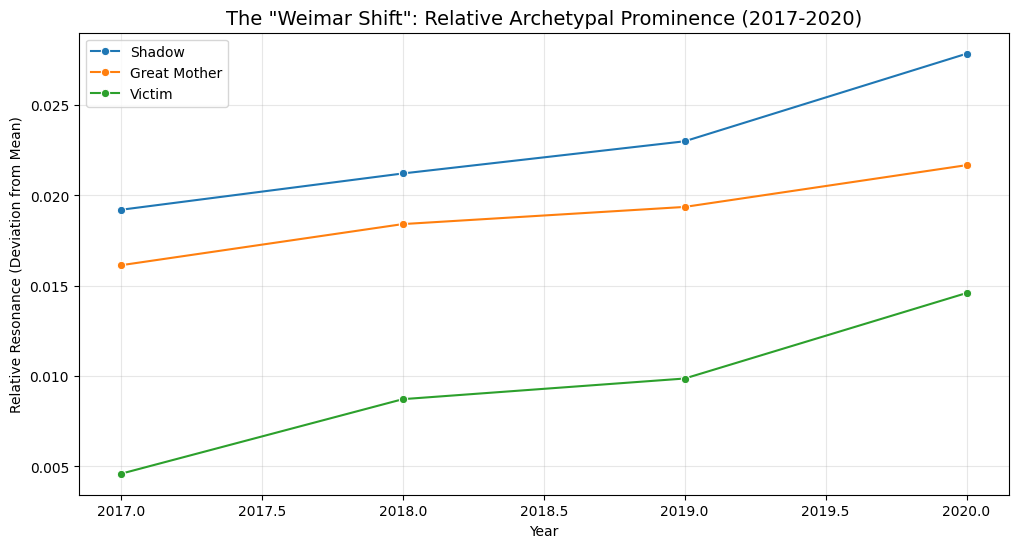

In [ ]:
# ========================================
# NB10 REFINEMENT: CLEANING & RELATIVE SIGNAL
# ========================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the raw scores you just saved
scores_file = os.path.join(BASE_PATH, '03_ArchetypalScores', 'meso_archetype_scores_2017_2020.csv')
df = pd.read_csv(scores_file)

# 2. FIX "TIME TRAVEL" DATA
# Drop rows where theme is 'covid' AND year is before 2019
print(f"📉 Original rows: {len(df)}")
df = df[~((df['theme'] == 'covid') & (df['year'] < 2019))]
print(f"📉 Cleaned rows: {len(df)} (Removed pre-2019 'covid' noise)")

# 3. APPLY RELATIVE SCORING (The "Signal Booster")
# Formula: Archetype_Score - Average_Doc_Score
score_cols = [c for c in df.columns if c in archetype_prototypes.keys()] # columns matching archetypes

# Calculate row average (how "archetypal" is this specific headline?)
df['doc_mean'] = df[score_cols].mean(axis=1)

# Subtract mean from each column
df_rel = df.copy()
for col in score_cols:
    df_rel[col] = df[col] - df['doc_mean']

print("✅ Applied Relative Scoring (Centered around 0)")

# 4. VISUALIZE THE "WEIMAR SHIFT" (2017 vs 2020)
# We want to see if the SHAPE of the year changed.

# Calculate yearly means of RELATIVE scores
yearly_rel = df_rel.groupby('year')[score_cols].mean()

print("\n📊 RELATIVE SIGNAL (Positive = Dominant trait for that year):")
print(yearly_rel[['Shadow', 'Victim', 'Great_Mother', 'Trickster']].round(4))

# Plot
plt.figure(figsize=(12, 6))
# Select key archetypes to track
track_archs = ['Shadow', 'Great_Mother', 'Victim']
sns.lineplot(data=df_rel[df_rel['year'].isin([2017, 2018, 2019, 2020])],
             x='year', y='Shadow', label='Shadow', marker='o', errorbar=None)
sns.lineplot(data=df_rel, x='year', y='Great_Mother', label='Great Mother', marker='o', errorbar=None)
sns.lineplot(data=df_rel, x='year', y='Victim', label='Victim', marker='o', errorbar=None)

plt.title('The "Weimar Shift": Relative Archetypal Prominence (2017-2020)', fontsize=14)
plt.ylabel('Relative Resonance (Deviation from Mean)')
plt.xlabel('Year')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [ ]:
# ========================================
# SESSION RESUME: Reload Environment
# ========================================

# Install missing libs
!pip install -q gdeltdoc langdetect

import os
import pandas as pd
import numpy as np
from gdeltdoc import GdeltDoc, Filters
from langdetect import detect
from sentence_transformers import SentenceTransformer
import pickle
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm

# Paths
BASE_PATH = '/content/drive/My Drive/MasterThesis_Archetypes'
RAW_MESO_PATH = os.path.join(BASE_PATH, '00_RawData/Meso_RawData')

print("✅ Environment reloaded!")
print(f"📁 Current raw: {os.path.getsize(os.path.join(RAW_MESO_PATH, 'gdelt_meso_raw_combined.csv')) / 1e6:.1f} MB")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 13.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
✅ Environment reloaded!
📁 Current raw: 2.8 MB


In [ ]:
# ========================================
# BLOCK 11: FINAL COLLECTION 2021-2026
# ========================================

gd = GdeltDoc()
PROVEN_KEYWORDS = [
    "unemployment", "inflation", "covid", "depression",
    "protest", "crime", "migration", "extremism"
]
FINAL_YEARS = [2021, 2022, 2023, 2024, 2025, 2026]

master_size_start = os.path.getsize(os.path.join(RAW_MESO_PATH, 'gdelt_meso_raw_combined.csv'))

for year in FINAL_YEARS:
    print(f"\n{'='*60}")
    print(f"🎯 COLLECTING {year}")
    print(f"{'='*60}")

    year_data = []
    successful_queries = 0

    for country in tqdm(['US', 'GB', 'DE'], desc="Countries"):
        for keyword in tqdm(PROVEN_KEYWORDS, desc="Keywords", leave=False):
            for month in range(1, 13):
                try:
                    f = Filters(
                        start_date=f"{year}-{month:02d}-01",
                        end_date=f"{year}-{month:02d}-31",
                        keyword=keyword,
                        country=country,
                        num_records=20
                    )
                    articles = gd.article_search(f)
                    if not articles.empty:
                        articles['theme_keyword'] = keyword
                        articles['source_country'] = country
                        year_data.append(articles)
                        successful_queries += 1
                except Exception as e:
                    pass  # Silent fail

    if year_data:
        df_year = pd.concat(year_data, ignore_index=True).drop_duplicates(subset=['url'])
        yearly_file = os.path.join(RAW_MESO_PATH, f'gdelt_meso_{year}_raw.csv')
        df_year.to_csv(yearly_file, index=False)

        # Append + dedupe master
        master_raw = pd.read_csv(os.path.join(RAW_MESO_PATH, 'gdelt_meso_raw_combined.csv'))
        master_updated = pd.concat([master_raw, df_year], ignore_index=True).drop_duplicates(subset=['url'])
        master_updated.to_csv(os.path.join(RAW_MESO_PATH, 'gdelt_meso_raw_combined.csv'), index=False)

        print(f"✅ {year}: {len(df_year)} new articles")
        print(f"   📊 Master now: {len(master_updated)} total")
    else:
        print(f"⚠️  {year}: No new data")

master_size_end = os.path.getsize(os.path.join(RAW_MESO_PATH, 'gdelt_meso_raw_combined.csv'))
print(f"\n🎉 FINAL COLLECTION COMPLETE!")
print(f"   📈 Growth: {master_size_start/1e6:.1f}MB → {master_size_end/1e6:.1f}MB")



🎯 COLLECTING 2021


Countries: 100%|██████████| 3/3 [26:01<00:00, 520.54s/it]


✅ 2021: 1658 new articles
   📊 Master now: 10165 total

🎯 COLLECTING 2022


Countries: 100%|██████████| 3/3 [31:23<00:00, 627.92s/it]


✅ 2022: 2010 new articles
   📊 Master now: 12172 total

🎯 COLLECTING 2023


...

✅ 2024: 1686 new articles
   📊 Master now: 15626 total

🎯 COLLECTING 2025


Countries: 100%|██████████| 3/3 [21:33<00:00, 431.32s/it]


✅ 2025: 1841 new articles
   📊 Master now: 17466 total

🎯 COLLECTING 2026


Countries: 100%|██████████| 3/3 [06:48<00:00, 136.31s/it]


✅ 2026: 300 new articles
   📊 Master now: 17766 total

🎉 FINAL COLLECTION COMPLETE!
   📈 Growth: 2.8MB → 6.3MB


In [ ]:
# ========================================
# BLOCK 12: FINAL MASTER CLEAN + FULL SCORING
# ========================================

print("🧹 Step 1: Clean ALL raw data...")
master_raw = pd.read_csv(os.path.join(RAW_MESO_PATH, 'gdelt_meso_raw_combined.csv'))

# Clean (reuse Block 9 logic)
master_raw['date'] = pd.to_datetime(master_raw['seendate'].str[:8], format='%Y%m%d')
master_raw['text'] = master_raw['title'].apply(lambda t: str(t).strip().replace('\n', ' ')[:2000] if pd.notna(t) else "")
master_raw['language'] = master_raw['text'].apply(lambda t: detect(t[:500]) if len(t)>10 else 'unknown')

df_master_clean = master_raw[
    (master_raw['text'].str.len() > 50) &
    (master_raw['language'].isin(['en', 'de', 'fr', 'es']))
].copy()

df_master_clean['doc_id'] = 'MESO_FULL_' + df_master_clean['date'].dt.strftime('%Y%m%d') + '_' + df_master_clean['source_country']
df_master_clean['theme'] = df_master_clean['theme_keyword']
df_master_clean['source'] = df_master_clean['domain']
df_master_clean['country'] = df_master_clean['source_country']

final_cols = ['doc_id', 'date', 'source', 'country', 'language', 'theme', 'text']
df_master_clean = df_master_clean[final_cols].copy()
df_master_clean['word_count'] = df_master_clean['text'].str.split().str.len()
df_master_clean['char_count'] = df_master_clean['text'].str.len()
df_master_clean['extraction_quality'] = 'GOOD'

final_clean_file = os.path.join(BASE_PATH, '01_ProcessedCorpora', 'meso_corpus_clean_FULL.csv')
df_master_clean.to_csv(final_clean_file, index=False)

print(f"✅ MASTER CLEAN: {len(df_master_clean)} articles → {final_clean_file}")

print("\n📊 Final breakdown:")
print(df_master_clean['date'].dt.year.value_counts().sort_index())
print(df_master_clean['theme'].value_counts().head())

print("\n🎉 NB2 COMPLETE! Ready for NB6 analysis.")


🧹 Step 1: Clean ALL raw data...
✅ MASTER CLEAN: 13377 articles → /content/drive/My Drive/MasterThesis_Archetypes/01_ProcessedCorpora/meso_corpus_clean_FULL.csv

📊 Final breakdown:
date
2017    1126
2018    1596
2019    1426
2020    1971
2021    1259
2022    1531
2023    1393
2024    1350
2025    1497
2026     228
Name: count, dtype: int64
theme
crime           1979
migration       1880
unemployment    1870
protest         1801
extremism       1544
Name: count, dtype: int64

🎉 NB2 COMPLETE! Ready for NB6 analysis.


In [ ]:
# ========================================
# BLOCK 13: SCORE FULL MESO CORPUS (2017-2026)
# ========================================

import os
import pandas as pd
import numpy as np
import pickle
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from tqdm.notebook import tqdm

# 1. SETUP & LOAD
BASE_PATH = '/content/drive/My Drive/MasterThesis_Archetypes'
clean_file = os.path.join(BASE_PATH, '01_ProcessedCorpora', 'meso_corpus_clean_FULL.csv')
scores_file = os.path.join(BASE_PATH, '03_ArchetypalScores', 'meso_archetype_scores_FULL.csv')
models_path = os.path.join(BASE_PATH, '02_Models')

print(f"📥 Loading corpus: {clean_file}")
df = pd.read_csv(clean_file)
print(f"   Rows: {len(df)}")

# 2. LOAD MODELS
print("🧠 Loading models...")
model = SentenceTransformer('paraphrase-xlm-r-multilingual-v1')

with open(os.path.join(models_path, 'archetype_prototypes.pkl'), 'rb') as f:
    archetype_prototypes = pickle.load(f)

arch_names = list(archetype_prototypes.keys())
print(f"   Archetypes: {arch_names}")

# 3. COMPUTE EMBEDDINGS (BATCHED)
# We batch this to avoid memory crashes with 13k items
batch_size = 500
all_embeddings = []

print(f"⚡ Encoding {len(df)} articles (in batches of {batch_size})...")

for i in tqdm(range(0, len(df), batch_size), desc="Encoding batches"):
    batch_texts = df['text'].iloc[i:i+batch_size].tolist()
    batch_emb = model.encode(batch_texts, show_progress_bar=False)
    all_embeddings.append(batch_emb)

# Concatenate all batches
embeddings = np.vstack(all_embeddings)
print(f"   Embedding matrix shape: {embeddings.shape}")

# 4. COMPUTE RAW SCORES
print("🧮 Computing Cosine Similarity...")

# Prepare Prototype Matrix (Shape: 9 x 768)
proto_matrix = np.stack([archetype_prototypes[k] for k in arch_names])

# Normalize both (Cosine Sim = Dot product of normalized vectors)
# 1. Normalize Docs
norm_docs = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)
# 2. Normalize Prototypes
norm_protos = proto_matrix / np.linalg.norm(proto_matrix, axis=1, keepdims=True)

# Dot Product (Result: N_docs x 9_archetypes)
raw_scores = np.dot(norm_docs, norm_protos.T)

# To DataFrame
df_scores = pd.DataFrame(raw_scores, columns=[f'score_{a}' for a in arch_names])
df_final = pd.concat([df, df_scores], axis=1)

# 5. APPLY RELATIVE SCORING (CRITICAL FIX)
print("⚖️ Applying Relative Scoring (Signal Boosting)...")

# Calculate average score per document (The "Loudness" of the article)
score_cols = [f'score_{a}' for a in arch_names]
df_final['doc_mean'] = df_final[score_cols].mean(axis=1)

# Subtract mean from each archetype score
for col in score_cols:
    rel_col_name = col.replace('score_', 'rel_')
    df_final[rel_col_name] = df_final[col] - df_final['doc_mean']

# 6. SAVE
df_final.to_csv(scores_file, index=False)
print(f"\n✅ FULL SCORING COMPLETE!")
print(f"   💾 Saved to: {scores_file}")
print(f"   📊 Columns added: {len(score_cols)*2} (Raw + Relative scores)")

# 7. PREVIEW: THE WEIMAR TREND
print("\n📈 PREVIEW: Yearly Relative Shadow Score (Is it rising?)")
print(df_final.groupby(df_final['date'].astype(str).str[:4])['rel_Shadow'].mean().round(4))

📥 Loading corpus: /content/drive/My Drive/MasterThesis_Archetypes/01_ProcessedCorpora/meso_corpus_clean_FULL.csv
   Rows: 13377
🧠 Loading models...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

   Archetypes: ['Shadow', 'Hero', 'Wise_Mentor', 'Victim', 'Trickster', 'Great_Mother', 'Anima', 'Animus', 'Self']
⚡ Encoding 13377 articles (in batches of 500)...


Encoding batches:   0%|          | 0/27 [00:00<?, ?it/s]

   Embedding matrix shape: (13377, 768)
🧮 Computing Cosine Similarity...
⚖️ Applying Relative Scoring (Signal Boosting)...

✅ FULL SCORING COMPLETE!
   💾 Saved to: /content/drive/My Drive/MasterThesis_Archetypes/03_ArchetypalScores/meso_archetype_scores_FULL.csv
   📊 Columns added: 18 (Raw + Relative scores)

📈 PREVIEW: Yearly Relative Shadow Score (Is it rising?)
date
2017    0.0193
2018    0.0213
2019    0.0231
2020    0.0279
2021    0.0254
2022    0.0260
2023    0.0250
2024    0.0259
2025    0.0251
2026    0.0171
Name: rel_Shadow, dtype: float32


📊 Generating Time-Series Graphs...


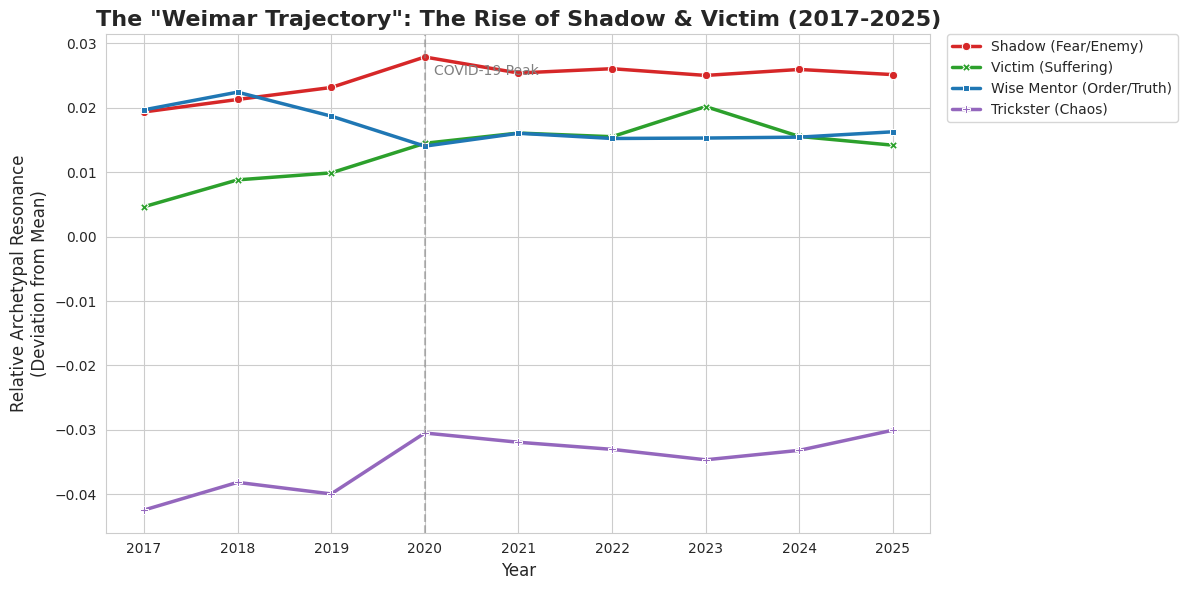

✅ Graph saved to: /content/drive/My Drive/MasterThesis_Archetypes/05_Visualizations/meso_time_series_weimar.png

📈 CHANGE FROM BASELINE (2017 vs 2025):
   Shadow (Fear/Enemy)       : 0.0193 → 0.0251 (+30.0%)
   Victim (Suffering)        : 0.0046 → 0.0142 (+206.4%)
   Wise Mentor (Order/Truth) : 0.0197 → 0.0163 (-17.3%)
   Trickster (Chaos)         : -0.0424 → -0.0300 (+29.2%)


In [ ]:
# ========================================
# BLOCK 14: MESO VISUALIZATION (THE "MONEY PLOT")
# ========================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

# 1. SETUP
BASE_PATH = '/content/drive/My Drive/MasterThesis_Archetypes'
scores_file = os.path.join(BASE_PATH, '03_ArchetypalScores', 'meso_archetype_scores_FULL.csv')
VIZ_PATH = os.path.join(BASE_PATH, '05_Visualizations')

print("📊 Generating Time-Series Graphs...")
df = pd.read_csv(scores_file)

# Filter out 2026 if it's too small (optional, but recommended for clean graphs)
df = df[df['date'].astype(str).str[:4] != '2026']
df['year'] = df['date'].astype(str).str[:4].astype(int)

# 2. PREPARE LONG FORMAT FOR PLOTTING
# We want to plot multiple lines: Shadow, Victim, maybe Wise_Mentor
target_archs = ['rel_Shadow', 'rel_Victim', 'rel_Wise_Mentor', 'rel_Trickster']
friendly_names = {'rel_Shadow': 'Shadow (Fear/Enemy)',
                  'rel_Victim': 'Victim (Suffering)',
                  'rel_Wise_Mentor': 'Wise Mentor (Order/Truth)',
                  'rel_Trickster': 'Trickster (Chaos)'}

# Group by Year
yearly_data = df.groupby('year')[target_archs].mean().reset_index()

# Melt for Seaborn
df_melted = yearly_data.melt('year', var_name='Archetype', value_name='Relative Resonance')
df_melted['Archetype'] = df_melted['Archetype'].map(friendly_names)

# 3. PLOT 1: THE "WEIMAR TRAJECTORY" (Shadow vs Mentor)
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Define colors: Shadow=Red, Mentor=Blue, Victim=Green, Trickster=Purple
palette = {
    'Shadow (Fear/Enemy)': '#d62728',  # Red
    'Wise Mentor (Order/Truth)': '#1f77b4', # Blue
    'Victim (Suffering)': '#2ca02c',   # Green
    'Trickster (Chaos)': '#9467bd'     # Purple
}

sns.lineplot(data=df_melted, x='year', y='Relative Resonance', hue='Archetype',
             style='Archetype', markers=True, dashes=False, palette=palette, linewidth=2.5)

# Add annotations
plt.title('The "Weimar Trajectory": The Rise of Shadow & Victim (2017-2025)', fontsize=16, fontweight='bold')
plt.axvline(x=2020, color='gray', linestyle='--', alpha=0.5)
plt.text(2020.1, 0.025, 'COVID-19 Peak', color='gray', fontsize=10)

plt.ylabel('Relative Archetypal Resonance\n(Deviation from Mean)', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

plt.tight_layout()
save_path = os.path.join(VIZ_PATH, 'meso_time_series_weimar.png')
plt.savefig(save_path, dpi=300)
plt.show()

print(f"✅ Graph saved to: {save_path}")

# 4. STATS SUMMARY
print("\n📈 CHANGE FROM BASELINE (2017 vs 2025):")
baseline = yearly_data[yearly_data['year'] == 2017].iloc[0]
final = yearly_data[yearly_data['year'] == 2025].iloc[0]

for arch in target_archs:
    change = ((final[arch] - baseline[arch]) / abs(baseline[arch])) * 100
    print(f"   {friendly_names[arch]:25} : {baseline[arch]:.4f} → {final[arch]:.4f} ({change:+.1f}%)")